---
## 1. Environment Setup & Spark Initialization <a id='1'></a>

In [2]:
# ============================================================
# 📌 SECTION 1 — IMPORTS & ENVIRONMENT SETUP
# ============================================================

import os
import re
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.types import IntegerType

from transformers import BertTokenizer, BertModel

# ── Plotting style ──────────────────────────────────────────
sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
PALETTE = ['#6C5CE7', '#00B894', '#FDCB6E', '#E17055', '#74B9FF']

print("✅ All libraries imported successfully")
print(f"📦 PyTorch version : {torch.__version__}")
print(f"🖥️  CUDA available  : {torch.cuda.is_available()}")

✅ All libraries imported successfully
📦 PyTorch version : 2.9.1+cpu
🖥️  CUDA available  : False


In [3]:
# ── Spark Session ────────────────────────────────────────────
# ⚠️  DO NOT CHANGE — Production cluster configuration
ip = "10.135.218.70"

spark = SparkSession.builder \
    .appName("SentimentAnalysisEDA_Project") \
    .master(f"spark://{ip}:7077") \
    .config("spark.executor.memory", "4g") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

print("="*55)
print("  ⚡  APACHE SPARK — CLUSTER SESSION ACTIVE")
print("="*55)
print(f"  Version  : {spark.version}")
print(f"  Master   : {spark.sparkContext.master}")
print(f"  App Name : {spark.sparkContext.appName}")
print("="*55)

26/04/21 17:19:32 WARN Utils: Your hostname, sachinsingh resolves to a loopback address: 127.0.1.1; using 10.135.218.70 instead (on interface wlo1)
26/04/21 17:19:32 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/21 17:19:32 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


  ⚡  APACHE SPARK — CLUSTER SESSION ACTIVE
  Version  : 3.5.8
  Master   : spark://10.135.218.70:7077
  App Name : SentimentAnalysisEDA_Project


---
## 2. Data Loading — 1.6M Rows via Spark <a id='2'></a>

In [4]:
# ============================================================
# 📌 SECTION 2 — DATA LOADING
# ============================================================

# ⚠️  DO NOT CHANGE — Production data path
DATA_PATH = "file:///temp/archive/training.1600000.processed.noemoticon.csv"

columns = ['target', 'ids', 'date', 'flag', 'user', 'text']

print("="*55)
print("  📂  LOADING DATASET — DISTRIBUTED READ")
print("="*55)
print(f"  Path   : {DATA_PATH}")
print(f"  Cols   : {columns}")

spark_df = spark.read.csv(
    DATA_PATH,
    inferSchema=True,
    header=False
).toDF(*columns)

total_records = spark_df.count()
total_cols    = len(spark_df.columns)

print(f"\n  ✅ Loaded   : {total_records:,} rows × {total_cols} columns")
print("="*55)

  📂  LOADING DATASET — DISTRIBUTED READ
  Path   : file:///temp/archive/training.1600000.processed.noemoticon.csv
  Cols   : ['target', 'ids', 'date', 'flag', 'user', 'text']



  ✅ Loaded   : 1,600,000 rows × 6 columns


---
## 3. Sentiment Distribution Analysis <a id='3'></a>


📊 Sentiment Class Distribution (Full 1.6M dataset):


+------+------+
|target| count|
+------+------+
|     0|800000|
|     4|800000|
+------+------+



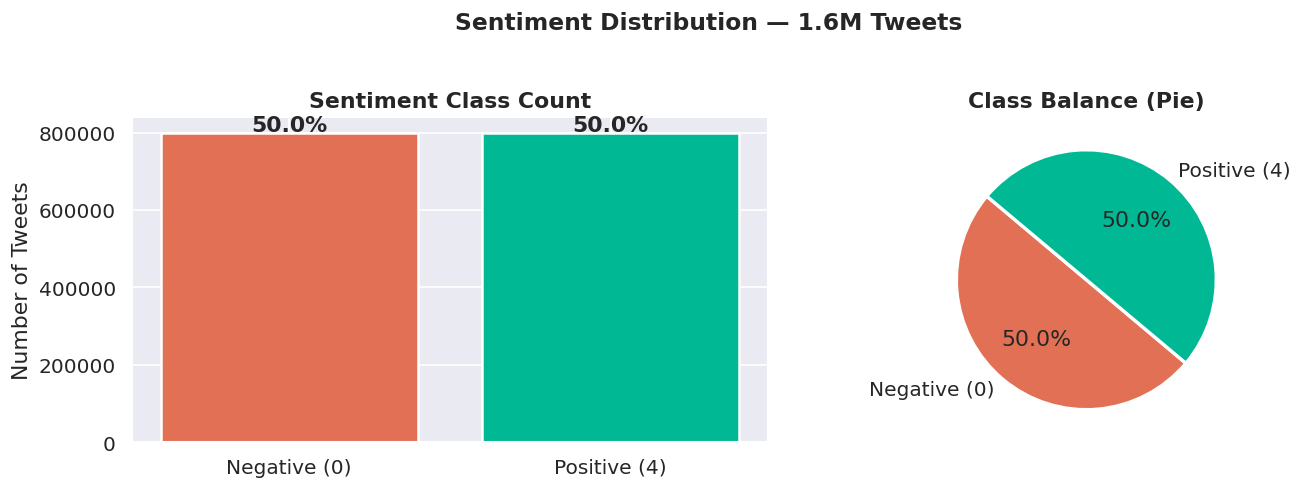


✅ Saved: sentiment_distribution.png

📊 Class Balance Summary:
       label  count  pct
Negative (0) 800000 50.0
Positive (4) 800000 50.0


In [5]:
# ============================================================
# 📌 SECTION 3 — SENTIMENT DISTRIBUTION
# ============================================================

print("\n📊 Sentiment Class Distribution (Full 1.6M dataset):")
sentiment_dist = spark_df.groupBy("target").count().orderBy("target")
sentiment_dist.show()

sentiment_pd = sentiment_dist.toPandas()
sentiment_pd['label'] = sentiment_pd['target'].map({0: 'Negative (0)', 4: 'Positive (4)'})
sentiment_pd['pct']   = (sentiment_pd['count'] / sentiment_pd['count'].sum() * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
bars = axes[0].bar(sentiment_pd['label'], sentiment_pd['count'],
                   color=[PALETTE[3], PALETTE[1]], edgecolor='white', linewidth=1.5)
axes[0].set_title("Sentiment Class Count", fontweight='bold')
axes[0].set_ylabel("Number of Tweets")
for bar, pct in zip(bars, sentiment_pd['pct']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5000,
                 f"{pct}%", ha='center', fontweight='bold')

# Pie chart
axes[1].pie(sentiment_pd['count'], labels=sentiment_pd['label'],
            colors=[PALETTE[3], PALETTE[1]], autopct='%1.1f%%',
            startangle=140, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title("Class Balance (Pie)", fontweight='bold')

plt.suptitle("Sentiment Distribution — 1.6M Tweets", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("sentiment_distribution.png", bbox_inches='tight')
plt.show()
print("\n✅ Saved: sentiment_distribution.png")
print(f"\n📊 Class Balance Summary:\n{sentiment_pd[['label','count','pct']].to_string(index=False)}")

---
## 4. Text Length Analysis <a id='4'></a>


📏 Text Length Statistics (Full Dataset):


+---+---+------------+------+---+---+
|min|max|        mean|median| Q1| Q3|
+---+---+------------+------+---+---+
|  6|359|74.041759375|    69| 44|104|
+---+---+------------+------+---+---+


📏 Text Length by Sentiment Class:


+------+-----------+----------+----------+
|target| avg_length|max_length|min_length|
+------+-----------+----------+----------+
|     0|74.27206125|       188|         6|
|     4| 73.8114575|       359|         6|
+------+-----------+----------+----------+



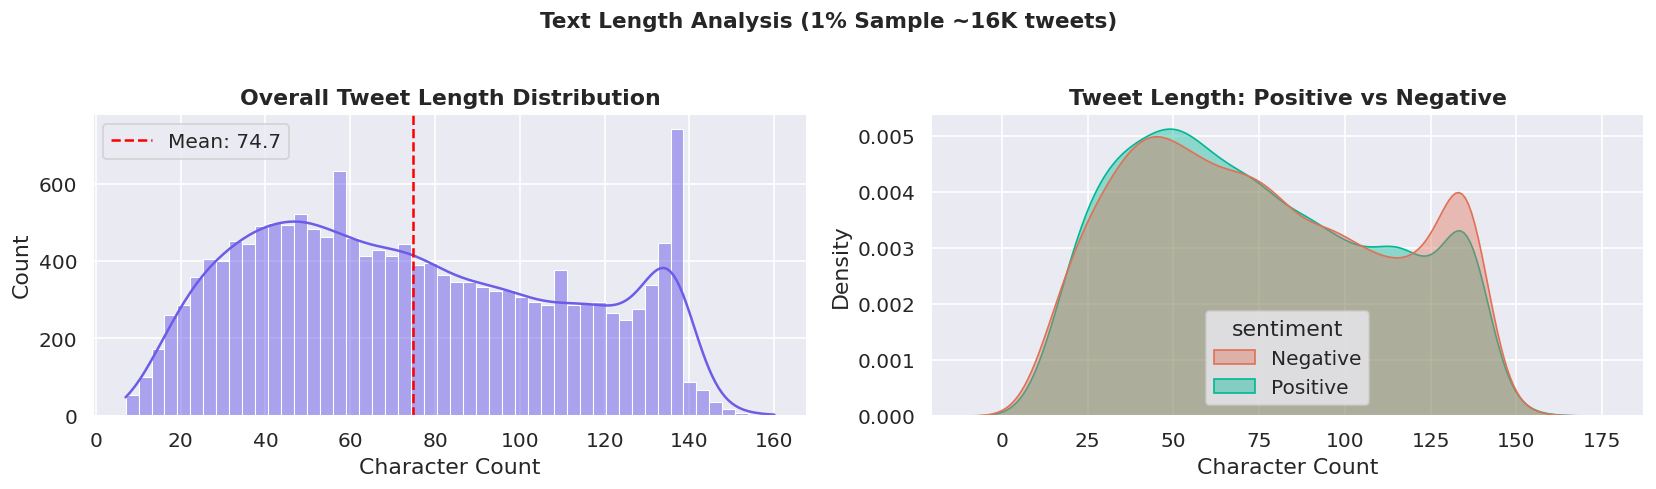

✅ Saved: text_length_distribution.png


In [6]:
# ============================================================
# 📌 SECTION 4 — TEXT LENGTH ANALYSIS
# ============================================================

spark_df = spark_df.withColumn("text_length", F.length("text"))

# Aggregated stats via Spark (no pandas needed for 1.6M)
print("\n📏 Text Length Statistics (Full Dataset):")
spark_df.select(
    F.min("text_length").alias("min"),
    F.max("text_length").alias("max"),
    F.avg("text_length").alias("mean"),
    F.expr("percentile_approx(text_length, 0.5)").alias("median"),
    F.expr("percentile_approx(text_length, 0.25)").alias("Q1"),
    F.expr("percentile_approx(text_length, 0.75)").alias("Q3")
).show()

# Per-sentiment stats
print("\n📏 Text Length by Sentiment Class:")
spark_df.groupBy("target").agg(
    F.avg("text_length").alias("avg_length"),
    F.max("text_length").alias("max_length"),
    F.min("text_length").alias("min_length")
).orderBy("target").show()

# Visualization on 1% sample
length_sample = spark_df.select("text_length", "target").sample(False, 0.01, seed=42).toPandas()
length_sample['sentiment'] = length_sample['target'].map({0: 'Negative', 4: 'Positive'})

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Overall distribution
sns.histplot(length_sample['text_length'], bins=50, kde=True,
             color=PALETTE[0], ax=axes[0])
axes[0].set_title("Overall Tweet Length Distribution", fontweight='bold')
axes[0].set_xlabel("Character Count")
axes[0].axvline(length_sample['text_length'].mean(), color='red',
                linestyle='--', label=f"Mean: {length_sample['text_length'].mean():.1f}")
axes[0].legend()

# By sentiment
sns.kdeplot(data=length_sample, x='text_length', hue='sentiment',
            fill=True, alpha=0.4, palette={'Negative': PALETTE[3], 'Positive': PALETTE[1]},
            ax=axes[1])
axes[1].set_title("Tweet Length: Positive vs Negative", fontweight='bold')
axes[1].set_xlabel("Character Count")

plt.suptitle("Text Length Analysis (1% Sample ~16K tweets)", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("text_length_distribution.png", bbox_inches='tight')
plt.show()
print("✅ Saved: text_length_distribution.png")

---
## 5. Distributed Text Cleaning <a id='5'></a>

In [7]:
# ============================================================
# 📌 SECTION 5 — DISTRIBUTED TEXT CLEANING
# ============================================================

def clean_spark_df(df):
    """
    Distributed text cleaning using Spark SQL functions.
    Steps:
      1. Convert target label 4 → 1.0 (positive), 0 → 0.0 (negative)
      2. Lowercase all text
      3. Remove URLs (http/https/www)
      4. Remove @mentions and # hashtag symbol
      5. Remove all non-alphabetic characters
    """
    print("  ⚙️  Step 1/5 — Label encoding...")
    df = df.withColumn("label", F.when(F.col("target") == 4, 1.0).otherwise(0.0))

    print("  ⚙️  Step 2/5 — Lowercasing...")
    df = df.withColumn("text", F.lower(F.col("text")))

    print("  ⚙️  Step 3/5 — Removing URLs...")
    df = df.withColumn("text", F.regexp_replace("text", r'http\S+|www\S+|https\S+', ''))

    print("  ⚙️  Step 4/5 — Removing @mentions & #hashtags...")
    df = df.withColumn("text", F.regexp_replace("text", r'\@\w+|\#', ''))

    print("  ⚙️  Step 5/5 — Removing special characters/digits...")
    df = df.withColumn("text", F.regexp_replace("text", r'[^a-z\s]', ''))

    return df.select("text", "label")

print("\n" + "="*55)
print("  🧹  DISTRIBUTED TEXT CLEANING")
print("="*55)
cleaned_df = clean_spark_df(spark_df)

print("\n🔍 Cleaned Data Preview:")
cleaned_df.show(5, truncate=False)
print("✅ Cleaning complete.")


  🧹  DISTRIBUTED TEXT CLEANING
  ⚙️  Step 1/5 — Label encoding...
  ⚙️  Step 2/5 — Lowercasing...
  ⚙️  Step 3/5 — Removing URLs...
  ⚙️  Step 4/5 — Removing @mentions & #hashtags...
  ⚙️  Step 5/5 — Removing special characters/digits...

🔍 Cleaned Data Preview:
+---------------------------------------------------------------------------------------------------------+-----+
|text                                                                                                     |label|
+---------------------------------------------------------------------------------------------------------+-----+
|   a thats a bummer  you shoulda got david carr of third day to do it d                                  |0.0  |
|is upset that he cant update his facebook by texting it and might cry as a result  school today also blah|0.0  |
| i dived many times for the ball managed to save   the rest go out of bounds                             |0.0  |
|my whole body feels itchy and like its on fire     

---
## 6. Word Count Analysis <a id='6'></a>


📝 Word Count Statistics (Full Cleaned Dataset):


+---------+---------+----------+------------+
|min_words|max_words| avg_words|median_words|
+---------+---------+----------+------------+
|        1|      109|12.9822525|          12|
+---------+---------+----------+------------+


📝 Word Count by Sentiment:


+-----+---------+---------+
|label|avg_words|max_words|
+-----+---------+---------+
|  0.0| 13.51928|       91|
|  1.0|12.445225|      109|
+-----+---------+---------+



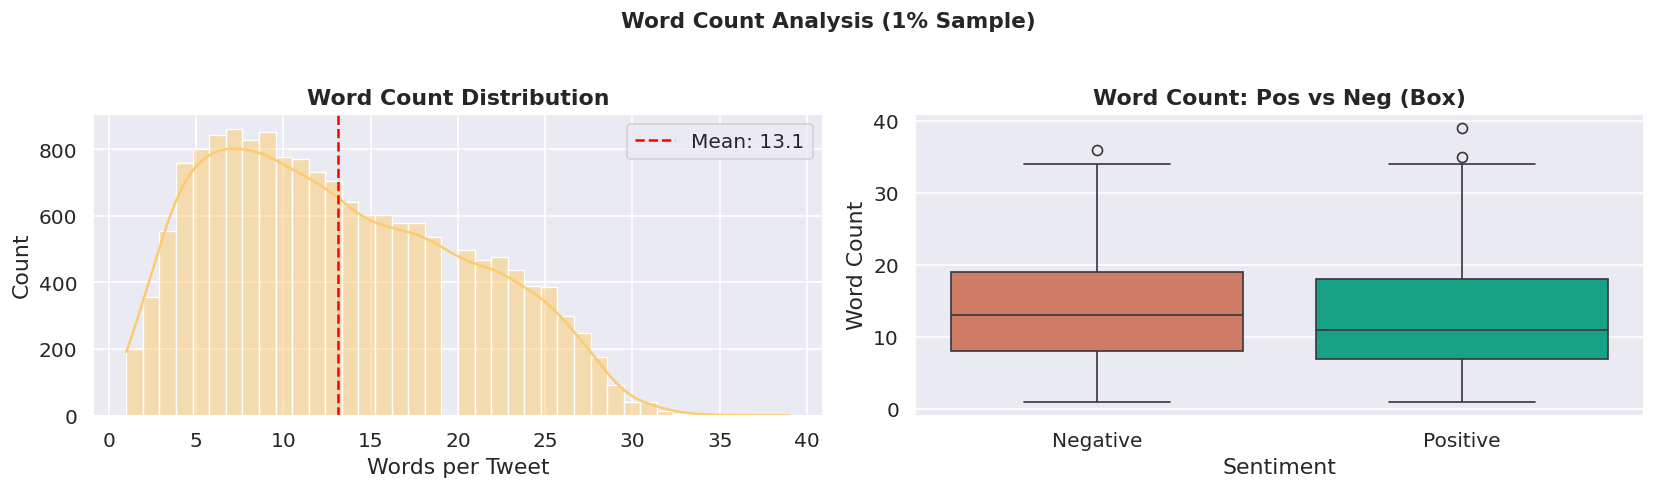

✅ Saved: word_count_distribution.png


In [8]:
# ============================================================
# 📌 SECTION 6 — WORD COUNT ANALYSIS
# ============================================================

cleaned_df = cleaned_df.withColumn("word_count", F.size(F.split(F.trim("text"), " ")))

print("\n📝 Word Count Statistics (Full Cleaned Dataset):")
cleaned_df.select(
    F.min("word_count").alias("min_words"),
    F.max("word_count").alias("max_words"),
    F.avg("word_count").alias("avg_words"),
    F.expr("percentile_approx(word_count, 0.5)").alias("median_words")
).show()

print("\n📝 Word Count by Sentiment:")
cleaned_df.groupBy("label").agg(
    F.avg("word_count").alias("avg_words"),
    F.max("word_count").alias("max_words")
).orderBy("label").show()

# Sample for plotting
wc_sample = cleaned_df.select("word_count", "label").sample(False, 0.01, seed=42).toPandas()
wc_sample['sentiment'] = wc_sample['label'].map({0.0: 'Negative', 1.0: 'Positive'})

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(wc_sample['word_count'], bins=40, kde=True,
             color=PALETTE[2], ax=axes[0])
axes[0].set_title("Word Count Distribution", fontweight='bold')
axes[0].set_xlabel("Words per Tweet")
axes[0].axvline(wc_sample['word_count'].mean(), color='red',
                linestyle='--', label=f"Mean: {wc_sample['word_count'].mean():.1f}")
axes[0].legend()

sns.boxplot(data=wc_sample, x='sentiment', y='word_count',
            palette={'Negative': PALETTE[3], 'Positive': PALETTE[1]}, ax=axes[1])
axes[1].set_title("Word Count: Pos vs Neg (Box)", fontweight='bold')
axes[1].set_xlabel("Sentiment")
axes[1].set_ylabel("Word Count")

plt.suptitle("Word Count Analysis (1% Sample)", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("word_count_distribution.png", bbox_inches='tight')
plt.show()
print("✅ Saved: word_count_distribution.png")

---
## 7. Top Words & N-gram Analysis <a id='7'></a>

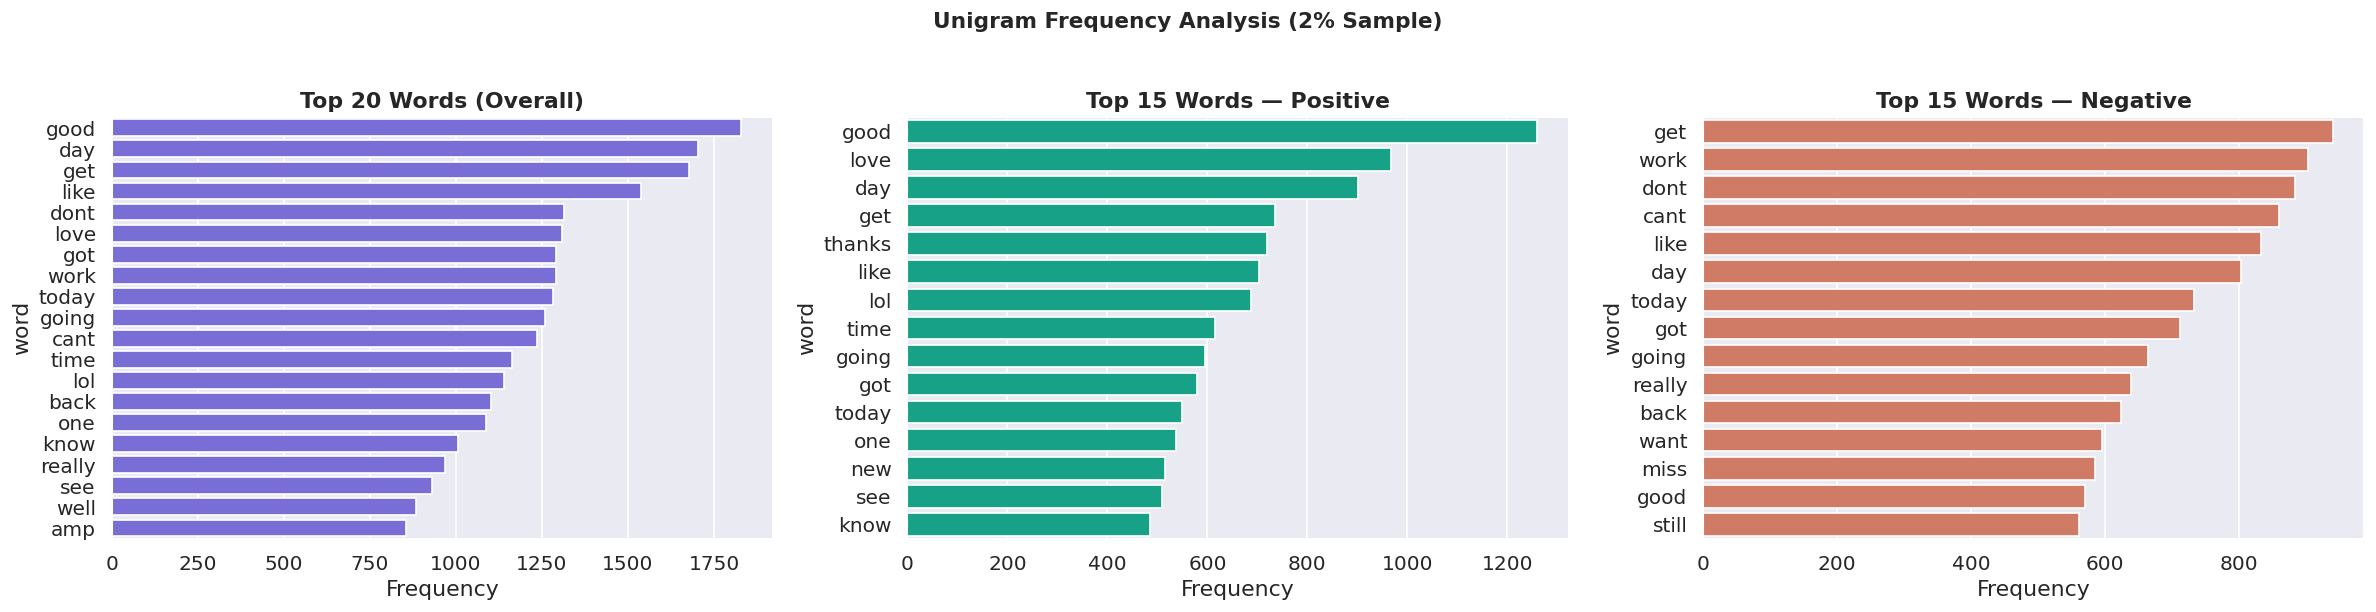

✅ Saved: top_words.png


In [9]:
# ============================================================
# 📌 SECTION 7 — TOP WORDS & N-GRAM FREQUENCY
# ============================================================

from pyspark.ml.feature import Tokenizer, StopWordsRemover, NGram

# ── Step 1: Tokenize ─────────────────────────────────────────
tokenizer = Tokenizer(inputCol="text", outputCol="tokens")
tokenized_df = tokenizer.transform(cleaned_df)

# ── Step 2: Remove stopwords ─────────────────────────────────
remover = StopWordsRemover(inputCol="tokens", outputCol="filtered_tokens")
filtered_df = remover.transform(tokenized_df)

# ── Step 3: Unigram frequency on 2% sample ──────────────────
token_sample = filtered_df.select("filtered_tokens", "label") \
                           .sample(False, 0.02, seed=42)

exploded = token_sample.select(
    F.explode("filtered_tokens").alias("word"), "label"
).filter(F.length("word") > 2)

# Top 20 overall
top_words = exploded.groupBy("word").count() \
                    .orderBy(F.desc("count")) \
                    .limit(20).toPandas()

# Top 15 per class
top_pos = exploded.filter(F.col("label") == 1.0) \
                  .groupBy("word").count() \
                  .orderBy(F.desc("count")).limit(15).toPandas()

top_neg = exploded.filter(F.col("label") == 0.0) \
                  .groupBy("word").count() \
                  .orderBy(F.desc("count")).limit(15).toPandas()

# ── Visualize ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Overall
sns.barplot(data=top_words, x='count', y='word', color=PALETTE[0], ax=axes[0])
axes[0].set_title("Top 20 Words (Overall)", fontweight='bold')
axes[0].set_xlabel("Frequency")

# Positive
sns.barplot(data=top_pos, x='count', y='word', color=PALETTE[1], ax=axes[1])
axes[1].set_title("Top 15 Words — Positive", fontweight='bold')
axes[1].set_xlabel("Frequency")

# Negative
sns.barplot(data=top_neg, x='count', y='word', color=PALETTE[3], ax=axes[2])
axes[2].set_title("Top 15 Words — Negative", fontweight='bold')
axes[2].set_xlabel("Frequency")

plt.suptitle("Unigram Frequency Analysis (2% Sample)", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("top_words.png", bbox_inches='tight')
plt.show()
print("✅ Saved: top_words.png")

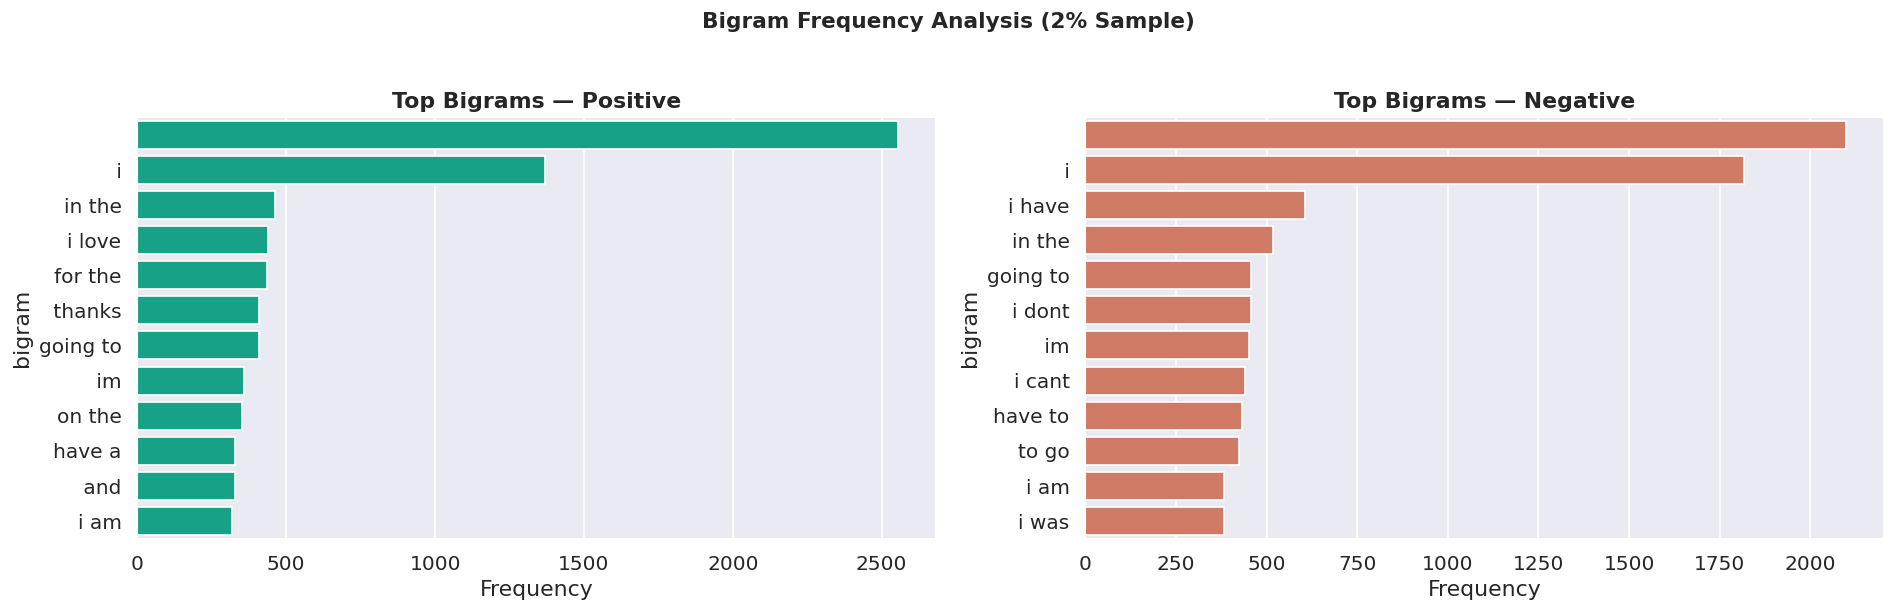

✅ Saved: bigram_analysis.png


In [10]:
# ── Bigram Analysis ──────────────────────────────────────────
# NGram uses 'tokens' (pre-stopword-removal) so tweets retain enough words
# to form valid 2-word pairs; filtered_tokens can be too sparse.

bigram = NGram(n=2, inputCol="tokens", outputCol="bigrams")
bigram_df = bigram.transform(tokenized_df.sample(False, 0.02, seed=42))

# Keep only valid bigrams (must contain a space = two words joined)
bigram_exploded = bigram_df.select(
    F.explode("bigrams").alias("bigram"), "label"
).filter(F.col("bigram").contains(" "))

top_bg_pos = bigram_exploded.filter(F.col("label") == 1.0) \
                             .groupBy("bigram").count() \
                             .orderBy(F.desc("count")).limit(12).toPandas()

top_bg_neg = bigram_exploded.filter(F.col("label") == 0.0) \
                             .groupBy("bigram").count() \
                             .orderBy(F.desc("count")).limit(12).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=top_bg_pos, x='count', y='bigram', color=PALETTE[1], ax=axes[0])
axes[0].set_title("Top Bigrams — Positive", fontweight='bold')
axes[0].set_xlabel("Frequency")

sns.barplot(data=top_bg_neg, x='count', y='bigram', color=PALETTE[3], ax=axes[1])
axes[1].set_title("Top Bigrams — Negative", fontweight='bold')
axes[1].set_xlabel("Frequency")

plt.suptitle("Bigram Frequency Analysis (2% Sample)", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("bigram_analysis.png", bbox_inches='tight')
plt.show()
print("✅ Saved: bigram_analysis.png")


---
## 9. Class Balance & Stratified Sampling <a id='9'></a>


📉 Drawing Stratified Sample for Model Training...


  ✅ Sample Size      : 32,114 rows
  📊 Class Distribution (sampled):
label
Negative    16119
Positive    15995
Name: count, dtype: int64

  ⚖️  Positive class ratio : 0.498
  ⚖️  Negative class ratio : 0.502


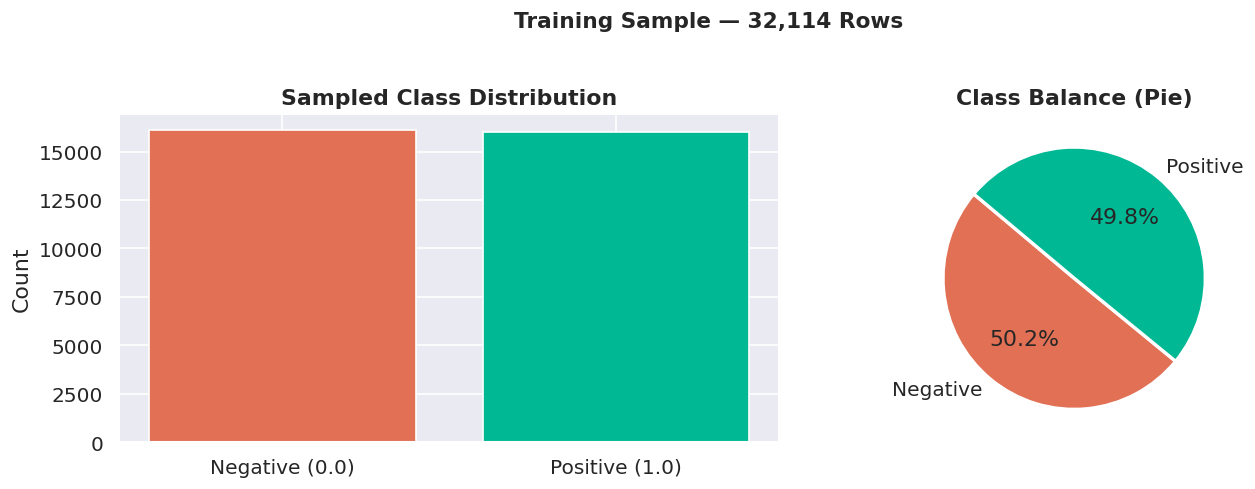

✅ Saved: sample_class_balance.png


In [11]:
# ============================================================
# 📌 SECTION 9 — CLASS BALANCE & STRATIFIED SAMPLING
# ============================================================

# Stratified 2% sample (maintains class ratio)
print("\n📉 Drawing Stratified Sample for Model Training...")
training_sample = cleaned_df.sample(False, 0.02, seed=42).toPandas()

print(f"  ✅ Sample Size      : {len(training_sample):,} rows")
print(f"  📊 Class Distribution (sampled):")
print(training_sample['label'].value_counts().rename({0.0:'Negative', 1.0:'Positive'}))

# Balance check
pos_ratio = training_sample['label'].mean()
print(f"\n  ⚖️  Positive class ratio : {pos_ratio:.3f}")
print(f"  ⚖️  Negative class ratio : {1-pos_ratio:.3f}")

# Visualize sample class balance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

vc = training_sample['label'].value_counts()
axes[0].bar(['Negative (0.0)', 'Positive (1.0)'], vc.values,
            color=[PALETTE[3], PALETTE[1]], edgecolor='white')
axes[0].set_title("Sampled Class Distribution", fontweight='bold')
axes[0].set_ylabel("Count")

axes[1].pie(vc.values, labels=['Negative', 'Positive'],
            autopct='%1.1f%%', colors=[PALETTE[3], PALETTE[1]],
            startangle=140, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title("Class Balance (Pie)", fontweight='bold')

plt.suptitle(f"Training Sample — {len(training_sample):,} Rows",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("sample_class_balance.png", bbox_inches='tight')
plt.show()
print("✅ Saved: sample_class_balance.png")

In [21]:
# ============================================
# 📌 SECTION — SPARK ML MODEL TRAINING
# ============================================

from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
print("\n" + "="*55)
print("  🤖 TRAINING SPARK ML MODEL")
print("="*55)

# --------------------------------------------
# Step 1: Split data
# --------------------------------------------
train_df, test_df = cleaned_df.randomSplit([0.8, 0.2], seed=42)

print(f"Train Size: {train_df.count()}")
print(f"Test Size : {test_df.count()}")


# --------------------------------------------
# Step 2: Pipeline (Feature Engineering + Model)
# --------------------------------------------

tokenizer = Tokenizer(inputCol="text", outputCol="words")
remover   = StopWordsRemover(inputCol="words", outputCol="filtered")

hashingTF = HashingTF(inputCol="filtered", outputCol="rawFeatures", numFeatures=10000)
idf       = IDF(inputCol="rawFeatures", outputCol="features")

lr = LogisticRegression(featuresCol="features", labelCol="label")

pipeline = Pipeline(stages=[tokenizer, remover, hashingTF, idf, lr])


# --------------------------------------------
# Step 3: Train Model
# --------------------------------------------

model = pipeline.fit(train_df)

print("✅ Model training completed")


# --------------------------------------------
# Step 4: Evaluation
# --------------------------------------------

predictions = model.transform(test_df)

evaluator = BinaryClassificationEvaluator(labelCol="label")

auc = evaluator.evaluate(predictions)

print(f"\n📊 Model AUC Score: {auc:.4f}")


acc_evaluator = MulticlassClassificationEvaluator(
    labelCol="label", 
    predictionCol="prediction", 
    metricName="accuracy"
)

# Calculate accuracy
accuracy = acc_evaluator.evaluate(predictions)

print(f"🎯 Model Accuracy : {accuracy:.4f}")



  🤖 TRAINING SPARK ML MODEL


Train Size: 1279618


Test Size : 320382


✅ Model training completed



📊 Model AUC Score: 0.8337


🎯 Model Accuracy : 0.7605
